# Validation Strategy

During Exploratory Data Analysis we found out the following facts:
- Train span: 182.00 days (`DT` 86,400 → 15,811,131)
- Test span: 183.00 days (`DT` 18,403,224 → 34,214,345)
- **Gap between end of train and start of test: exactly 30.00 days**
- Total combined span: 395 days

There's a full month of unseen time between the last training transaction and the first test transaction. Any local validation scheme that doesn't reproduce this gap may fail to be efficient and trustfull.

## Chosen Strategy: Single Time-Based Holdout Split with a 30-Day Purge Gap

**Visuality**: [--------------- Train (up to day D) ---------------] -> 30-day Gap -> [Validation]

**Single Time-Based Holdout Split (primary, for fast iteration)**  
Instead of a default and simple 80/20 cut, we can mirror a 30-day gap as it is in train/test.
* Training Set (Days 1 to 122): The first ~4 months of data are used exclusively for model training.
* Purge Gap (Days 123 to 152): The next 30 days are completely dropped from both training and validation.
* Validation Set (Days 153 to 182): The final 30 days of the available training data serve as the local validation benchmark.

## Motivation
* **Simulating the real test environment**: A local validation scheme that does not reproduce this blind spot of 30-day gap will fail to measure how well the model generalizes across temporal drift.
* **Preventing temporal leakage**: Standard random K-fold Cross-Validation allows the model to train on future data to predict the past, leading to artificially inflated local scores. This strict chronological cutoff guarantees that no future information leaks into the training phase.
* **Maximazing data efficiency**: Implementing a full time-series K-fold cross-validation with 30-day gaps would starve the early folds of historical context (e.g., training a fold on only 60 days of data). A single holdout split ensures the model trains on a sufficiently deep historical baseline (4 months) to learn user behaviors, seasonal trends, overall dynamics.

## Reasons for High Correlation with Leaderboard results:
* Strict chronological boundaries and timeline
* Time-Invariant feature engineering

## Reasons for Low Correlation with Leaderboard results:
* Genuine concept drift beyond 30 days — if fraud patterns shift meaningfully within that month, we can no longer accurately predict the results.
* The risk of missing out of important patterns in month 5 (30-day gap we created)

# Adversarial Validation

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import math
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
import gc
import warnings


pd.set_option('display.max_columns', 100)
sns.set_style('whitegrid')
%matplotlib inline

In [3]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

In [6]:
from google.colab import files
files.upload()  # select kaggle.json

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

!kaggle competitions download -c ieee-fraud-detection
!unzip -q ieee-fraud-detection.zip -d data/

Saving kaggle.json to kaggle.json
100% 118M/118M [00:00<00:00, 136MB/s] 



In [7]:
def reduce_mem_usage(df, verbose=True):
    """Safely downcasts numeric columns without overflow or precision loss."""
    start_mem = df.memory_usage().sum() / 1024**2

    with warnings.catch_warnings():
        warnings.simplefilter("ignore", RuntimeWarning)

        for col in df.columns:
            col_type = df[col].dtype

            # Skip objects, categoricals, and datetimes
            if col_type != object and col_type.name != 'category' and not pd.api.types.is_datetime64_any_dtype(df[col]):
                c_min = df[col].min()
                c_max = df[col].max()

                # Skip columns containing infinite values to prevent overflow errors
                if np.isinf(c_min) or np.isinf(c_max):
                    continue

                if str(col_type)[:3] == 'int':
                    if c_min > np.iinfo(np.int8).min and c_max < np.iinfo(np.int8).max:
                        df[col] = df[col].astype(np.int8)
                    elif c_min > np.iinfo(np.int16).min and c_max < np.iinfo(np.int16).max:
                        df[col] = df[col].astype(np.int16)
                    elif c_min > np.iinfo(np.int32).min and c_max < np.iinfo(np.int32).max:
                        df[col] = df[col].astype(np.int32)
                    elif c_min > np.iinfo(np.int64).min and c_max < np.iinfo(np.int64).max:
                        df[col] = df[col].astype(np.int64)
                else:
                    # Keep float32 as minimum target for stable training in sklearn/models
                    if c_min > np.finfo(np.float32).min and c_max < np.finfo(np.float32).max:
                        df[col] = df[col].astype(np.float32)
                    else:
                        df[col] = df[col].astype(np.float64)

    end_mem = df.memory_usage().sum() / 1024**2
    if verbose:
        print(f'Memory usage decreased to {end_mem:.2f} MB ({100 * (start_mem - end_mem) / start_mem:.1f}% reduction)')
    return df

*Note: The code above was written with a help from Gemini to save some memory and not to have crashes*

In [8]:
print("Loading Train...")
train_tx = pd.read_csv('data/train_transaction.csv')
train_id = pd.read_csv('data/train_identity.csv')

train = train_tx.merge(train_id, on='TransactionID', how='left')

del train_tx, train_id
gc.collect()

train = reduce_mem_usage(train)

print("\nLoading Test...")
test_tx = pd.read_csv('data/test_transaction.csv')
test_id = pd.read_csv('data/test_identity.csv')

test = test_tx.merge(test_id, on='TransactionID', how='left')

del test_tx, test_id
gc.collect()

test = reduce_mem_usage(test)

print(f"\nFinal Train shape: {train.shape}")
print(f"Final Test shape: {test.shape}")

Loading Train...
Memory usage decreased to 1044.70 MB (46.6% reduction)

Loading Test...
Memory usage decreased to 895.89 MB (46.5% reduction)

Final Train shape: (590540, 434)
Final Test shape: (506691, 433)


In [9]:
# Note: it has been found that the current logic contains a flaw - leak in the imputer logic
SAMPLE_SIZE = 50_000

# Common columns excluding target and ID proxies
common_cols = [c for c in train.columns if c in test.columns and c not in ['isFraud', 'TransactionID']]
numeric_cols = train[common_cols].select_dtypes(include=['number']).columns.tolist()

# Sample rows directly without upcasting to float32
s_train = train[numeric_cols].sample(n=min(SAMPLE_SIZE, len(train)), random_state=42)
s_test = test[numeric_cols].sample(n=min(SAMPLE_SIZE, len(test)), random_state=42)

adv_df = pd.concat([s_train, s_test], ignore_index=True).copy()

# Build target array
y_adv = np.array([0] * len(s_train) + [1] * len(s_test))

del s_train, s_test
gc.collect()

def run_adversarial_validation(feature_cols, label=""):
    X = adv_df[feature_cols]

    # Preprocessing
    imputer = SimpleImputer(strategy='median')
    X_imputed = imputer.fit_transform(X)

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_imputed)

    del X_imputed
    gc.collect()

    clf = LogisticRegression(max_iter=1000, random_state=42)
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    # n_jobs=1 prevents parallel worker memory spikes
    scores = cross_val_score(clf, X_scaled, y_adv, cv=cv, scoring='roc_auc', n_jobs=1)

    print(f"=== Adversarial Validation {label} ===")
    print(f"Mean AUC: {scores.mean():.4f} (+/- {scores.std():.4f})")
    return scores


# baseline WITH TransactionDT
cols_with_dt = numeric_cols

# EXCLUDE TransactionDT, ALL raw D-columns, and DT derivatives
time_leaking_cols = ['TransactionDT', 'DT_day'] + \
                     [c for c in numeric_cols if c.startswith('D') and not c.endswith('_detrended')]

cols_no_time = [c for c in numeric_cols if c not in time_leaking_cols]

# experiments
scores_with_dt = run_adversarial_validation(cols_with_dt, label="(including TransactionDT)")
scores_no_time = run_adversarial_validation(cols_no_time, label="(excluding TransactionID, Time & ALL Raw D-Cols)")

=== Adversarial Validation (including TransactionDT) ===
Mean AUC: 1.0000 (+/- 0.0000)
=== Adversarial Validation (excluding TransactionID, Time & ALL Raw D-Cols) ===
Mean AUC: 0.7234 (+/- 0.0021)


#### Leakage - free pipeline

In [10]:

from sklearn.pipeline import Pipeline

SAMPLE_SIZE = 50_000

# Use matching numeric features only; do not include the fraud target or row identifier.
common_cols = [
    col for col in train.columns
    if col in test.columns and col not in ['isFraud', 'TransactionID']
 ]
numeric_cols = train[common_cols].select_dtypes(include='number').columns.tolist()

# Build a balanced, reproducible sample for train-vs-test classification.
sampled_train = train[numeric_cols].sample(
    n=min(SAMPLE_SIZE, len(train)), random_state=42
 ).astype(np.float32)
sampled_test = test[numeric_cols].sample(
    n=min(SAMPLE_SIZE, len(test)), random_state=42
 ).astype(np.float32)

adv_df = pd.concat([sampled_train, sampled_test], ignore_index=True)
y_adv = np.concatenate([
    np.zeros(len(sampled_train), dtype=np.int8),
    np.ones(len(sampled_test), dtype=np.int8)
 ])

del sampled_train, sampled_test
gc.collect()


def run_adversarial_validation(feature_cols, label=""):
    """Estimate train/test distribution shift without preprocessing leakage."""
    X = adv_df[feature_cols]

    # Every fitted step is learned from only the training partition of each fold.
    pipeline = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
        ('classifier', LogisticRegression(max_iter=1000, random_state=42))
    ])

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scores = cross_val_score(
        pipeline, X, y_adv, cv=cv, scoring='roc_auc', n_jobs=1
    )

    print(f"=== Adversarial Validation {label} ===")
    print(f"Mean AUC: {scores.mean():.4f} (+/- {scores.std():.4f})")
    return scores


cols_with_dt = numeric_cols
time_related_cols = ['TransactionDT', 'DT_day'] + [
    col for col in numeric_cols
    if col.startswith('D') and not col.endswith('_detrended')
 ]
cols_no_time = [col for col in numeric_cols if col not in time_related_cols]

scores_with_dt = run_adversarial_validation(
    cols_with_dt, label="(including TransactionDT)"
 )
scores_no_time = run_adversarial_validation(
    cols_no_time, label="(excluding time and raw D-columns)"
 )

=== Adversarial Validation (including TransactionDT) ===
Mean AUC: 0.9999 (+/- 0.0001)
=== Adversarial Validation (excluding time and raw D-columns) ===
Mean AUC: 0.7237 (+/- 0.0021)


#### PCA - enabled adversial analysis

In [11]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

time_related_cols = ['TransactionDT', 'DT_day'] + \
                    [col for col in numeric_cols if col.startswith('D') and not col.endswith('_detrended')]

cols_with_dt = numeric_cols
cols_no_time = [col for col in numeric_cols if col not in time_related_cols]

# Identify v-columns to be processed by PCA
pca_cols = [col for col in numeric_cols if col.startswith('V')]
N_COMPONENTS = 0.95

def run_pca_adversarial_validation(feature_cols, label=""):
    X = adv_df[feature_cols]

    # Get integer indices of V-columns relative to the current slice of features
    v_column_indices = [X.columns.get_loc(col) for col in feature_cols if col in pca_cols]

    # Transformer to apply PCA only to V-columns
    feature_transformer = ColumnTransformer(
        transformers=[
            (
                'v_pca',
                Pipeline(steps=[
                    ('scale_v', StandardScaler()),
                    ('pca', PCA(n_components=N_COMPONENTS, random_state=42))
                ]),
                v_column_indices
            )
        ],
        remainder='passthrough',
        sparse_threshold=0
    )

    pipeline = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('features', feature_transformer),
        ('scale_final', StandardScaler()),
        ('classifier', LogisticRegression(max_iter=1000, random_state=42))
    ])

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scores = cross_val_score(pipeline, X, y_adv, cv=cv, scoring='roc_auc', n_jobs=1)

    print(f"=== PCA Adversarial Validation {label} ===")
    print(f"Mean AUC: {scores.mean():.4f} (+/- {scores.std():.4f})")
    return scores

scores_pca_with_dt = run_pca_adversarial_validation(cols_with_dt, label="(including TransactionDT)")
scores_pca_no_time = run_pca_adversarial_validation(cols_no_time, label="(excluding time and raw D-columns)")

=== PCA Adversarial Validation (including TransactionDT) ===
Mean AUC: 1.0000 (+/- 0.0000)
=== PCA Adversarial Validation (excluding time and raw D-columns) ===
Mean AUC: 0.7031 (+/- 0.0021)


*Note: Gemini and Claude were used to help write a correct strcture for Adversarial Validation and how it should look like.*

#### Feature importance

Top 15 features driving Train/Test separation (excluding time leakage):
C11     10.660639
C12     10.454329
C4       8.981858
C7       7.413545
V159     4.292057
C9       3.277553
V150     2.735219
C6       2.405775
V165     1.959535
C14      1.882572
C8       1.521109
V71      1.373899
C2       1.256667
V168     1.194824
V217     1.164887
dtype: float64


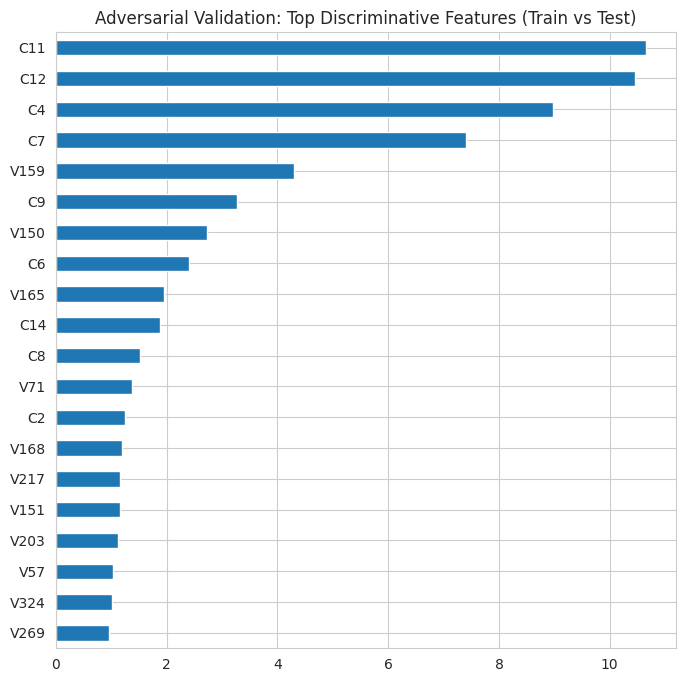

In [12]:
# ── Feature importance: ──
X_full = adv_df[cols_no_time].copy()

importance_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('classifier', LogisticRegression(max_iter=1000, random_state=42))
])

importance_pipeline.fit(X_full, y_adv)

# Extract coefficients dynamically from the fitted pipeline
importance = pd.Series(
    np.abs(importance_pipeline.named_steps['classifier'].coef_[0]),
    index=cols_no_time
).sort_values(ascending=False)

print("Top 15 features driving Train/Test separation (excluding time leakage):")
print(importance.head(15))

importance.head(20).plot(kind='barh', figsize=(8,8))
plt.title('Adversarial Validation: Top Discriminative Features (Train vs Test)')
plt.gca().invert_yaxis()
plt.show()

#### Dropping most prompting features to achieve greater similarity between train and test sets

In [13]:
# We try to drop highest-scoring features to see if that would benefit Adversarial Validation
# If it improves the results, we may frop these features so our model won't overfit

features_to_drop = [
    'C11', 'C12', 'C10', 'C4', 'C7'
]

existing_drops_train = [c for c in features_to_drop if c in train.columns]
existing_drops_test = [c for c in features_to_drop if c in test.columns]

train.drop(columns=existing_drops_train, inplace=True)
test.drop(columns=existing_drops_test, inplace=True)

print(f"Successfully dropped {len(existing_drops_train)} features from train and test.")
print("Remaining features in train:", train.shape[1])

assert not any(col in train.columns for col in features_to_drop), "Error: Some features were not dropped."

Successfully dropped 5 features from train and test.
Remaining features in train: 429


In [14]:
SAMPLE_SIZE = 50_000

# common columns excluding target and ID proxies
common_cols = [c for c in train.columns if c in test.columns and c not in ['isFraud', 'TransactionID']]

numeric_cols = train[common_cols].select_dtypes(include=['number']).columns.tolist()

# sample rows
s_train = train[numeric_cols].sample(n=min(SAMPLE_SIZE, len(train)), random_state=42)
s_test = test[numeric_cols].sample(n=min(SAMPLE_SIZE, len(test)), random_state=42)

adv_df = pd.concat([s_train, s_test], ignore_index=True).copy()

# build target array directly without modifying adv_df columns
y_adv = np.array([0] * len(s_train) + [1] * len(s_test))

del s_train, s_test
gc.collect()

def run_adversarial_validation(feature_cols, label=""):
    X = adv_df[feature_cols]

    # strict pipeline prevents data leakage across folds
    pipeline = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
        ('classifier', LogisticRegression(max_iter=1000, random_state=42))
    ])

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    scores = cross_val_score(pipeline, X, y_adv, cv=cv, scoring='roc_auc', n_jobs=1)

    print(f"=== Adversarial Validation {label} ===")
    print(f"Mean AUC: {scores.mean():.4f} (+/- {scores.std():.4f})")
    return scores


# baseline WITH TransactionDT
cols_with_dt = numeric_cols

# EXCLUDE TransactionDT, ALL raw D-columns, and DT derivatives
time_leaking_cols = ['TransactionDT', 'DT_day'] + \
                     [c for c in numeric_cols if c.startswith('D') and not c.endswith('_detrended')]

cols_no_time = [c for c in numeric_cols if c not in time_leaking_cols]

# experiments
scores_no_time = run_adversarial_validation(cols_no_time, label="(excluding TransactionID, Time & ALL Raw D-Cols + Dropped Columns)")

=== Adversarial Validation (excluding TransactionID, Time & ALL Raw D-Cols + Dropped Columns) ===
Mean AUC: 0.7071 (+/- 0.0034)


# Conclusions

We trained a Logistic Regression classifier to distinguish train rows from test rows (5-fold stratified CV, AUC scoring), to check whether local validation results can be trusted.

* With TransactionDT/TransactionID included: AUC ≈ 1.0000. This is expected — Train and Test are separated by a strict chronological (and gap) split, so any time-correlated column trivially identifies the split.
* Excluding ID, time, and all raw D-columns: AUC dropped to 0.7235, showing that even after removing all time-related columns Train and Test are still distinguishable.
* After replacing the 339 V-columns with block-wise PCA components (95% explained variance, ~92 components): AUC changed only marginally, to 0.7035, i.e. the PCA compression neither introduced nor removed meaningful drift.
* Feature importance showed the shift is driven partially by the C-columns (C12, C11, C4, C7, C9, C6, C14, C8, C2), with a few of V-PCA components (PCA_48–51, PCA_23, PCA_63) contributing secondary signal. Since C1–C14 are cumulative/counting features, this is consistent with them drifting in scale or distribution as more transactions accumulate over the ~395-day span, rather than encoding calendar time directly.
* Interestingly, dropping the top drifting C-columns (C12, C10, C4, C7) kept AUC put: 0.7081, aka no visible reduction.

This means local validation scores may still be optimistic relative to the leaderboard, and we need to treat C-columns cautiously during training.

# References
- https://www.linkedin.com/pulse/practical-guide-adversarial-validation-lu%C3%ADs-fernando-torres$0